# 02 — Identity / Incidence Matrix `H_aug(t)`

`H_aug(t) = [ H_spatial(t) | H_lineage | H_functional | H_anastomosis(t) ]`

This notebook assembles the four hyperedge sources produced/used in notebook 01 into a single sparse incidence ("identity") matrix per timepoint, and visualizes its structure and evolution over developmental time.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, os.path.abspath('..'))

from dhgnn_lib.cell_universe import CellUniverse
from dhgnn_lib import hyperedges, incidence, visualization

RAW_DIR = '../raw_dataset'
OUTPUT_DIR = '../output_tables'

universe = CellUniverse.build(RAW_DIR, OUTPUT_DIR)
print(f'N = {len(universe)} cells')


N = 1625 cells


## 1. Load the hyperedge store

`HyperedgeStore` loads all four lookup tables and exposes the static lineage/functional hyperedge sets plus per-timepoint spatial/anastomosis sets.

In [2]:
store = hyperedges.HyperedgeStore(RAW_DIR, OUTPUT_DIR, universe)
print(f'lineage hyperedges (static):    {store.lineage().num_edges}')
print(f'functional hyperedges (static): {store.functional().num_edges}')
print(f'spatial/anastomosis timepoints:  {store.timepoints[0]}..{store.timepoints[-1]} '
      f'({len(store.timepoints)} timepoints with spatial communities)')


lineage hyperedges (static):    642
functional hyperedges (static): 4436
spatial/anastomosis timepoints:  15..190 (146 timepoints with spatial communities)


## 2. Assemble `H_aug(t)` for a sample timepoint

In [3]:
T_SAMPLE = 100
spatial = store.spatial(T_SAMPLE)
anastomosis = store.anastomosis(T_SAMPLE)
print(f'spatial hyperedges at t={T_SAMPLE}:     {spatial.num_edges}')
print(f'anastomosis hyperedges at t={T_SAMPLE}: {anastomosis.num_edges}')

batch = incidence.assemble(len(universe), spatial, store.lineage(), store.functional(), anastomosis)
print(f'H_aug(t={T_SAMPLE}): {batch.num_nodes} cells x {batch.num_edges} hyperedges, '
      f'nnz={batch.cell_index.shape[0]}')


spatial hyperedges at t=100:     27
anastomosis hyperedges at t=100: 12
H_aug(t=100): 1625 cells x 5117 hyperedges, nnz=15383


### Hyperedge composition by type

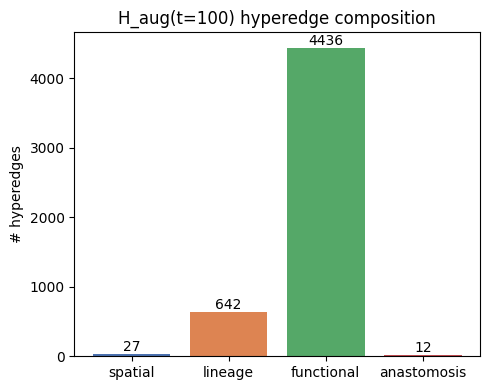

In [4]:
fig = visualization.plot_edge_type_counts(batch, title=f'H_aug(t={T_SAMPLE}) hyperedge composition')
plt.show()


### Incidence sparsity pattern

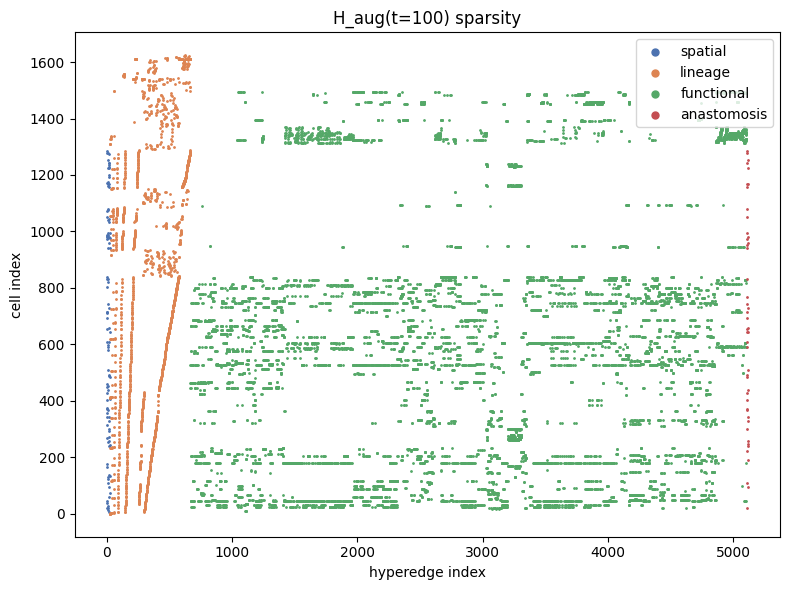

In [5]:
fig = visualization.plot_incidence_sparsity(batch, title=f'H_aug(t={T_SAMPLE}) sparsity')
plt.show()


### Hyperedge size distribution

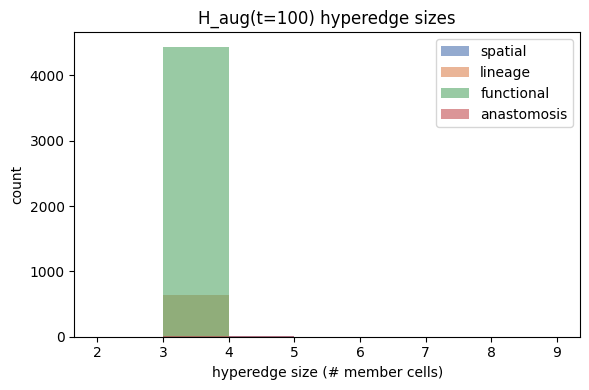

In [6]:
fig = visualization.plot_hyperedge_size_distribution(batch, title=f'H_aug(t={T_SAMPLE}) hyperedge sizes')
plt.show()


### Local hypergraph neighbourhood (bipartite cell <-> hyperedge view)

A small bipartite subgraph around a handful of early founder cells.

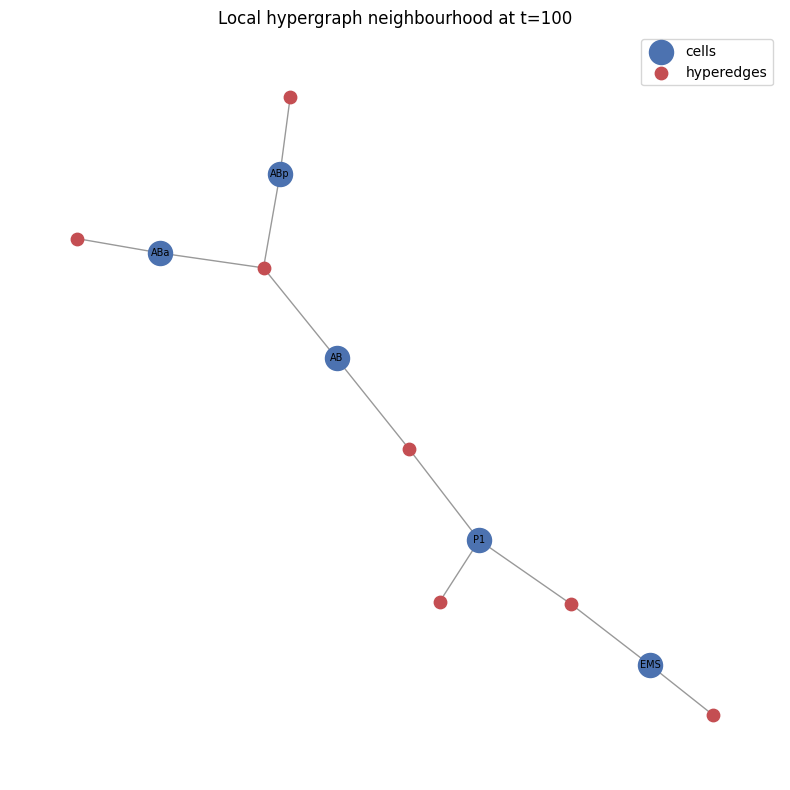

In [7]:
sample_cells = [universe.get(c) for c in ['AB', 'P1', 'ABa', 'ABp', 'EMS'] if c in universe]
fig = visualization.plot_hypergraph_subgraph(
    batch, universe.names, sample_cells, max_edges=40,
    title=f'Local hypergraph neighbourhood at t={T_SAMPLE}',
)
plt.show()


## 3. Evolution of `H_aug(t)` over developmental time

Spatial and anastomosis hyperedge counts change with t; lineage and functional are fixed.

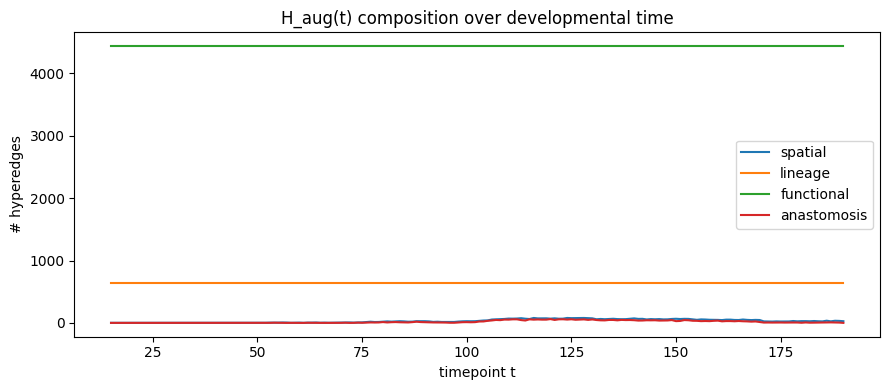

,spatial,lineage,functional,anastomosis
count,146.000000,146.0,146.0,146.000000
mean,36.547945,642.0,4436.0,21.609589
std,25.149232,0.0,0.0,20.022530
min,1.000000,642.0,4436.0,0.000000
25%,15.000000,642.0,4436.0,4.000000
50%,29.000000,642.0,4436.0,12.000000
75%,61.000000,642.0,4436.0,41.000000
max,79.000000,642.0,4436.0,61.000000


In [8]:
rows = []
for t in store.timepoints:
    rows.append({
        't': t,
        'spatial': store.spatial(t).num_edges,
        'lineage': store.lineage().num_edges,
        'functional': store.functional().num_edges,
        'anastomosis': store.anastomosis(t).num_edges,
    })
evolution_df = pd.DataFrame(rows).set_index('t')
fig = visualization.plot_spatial_evolution(evolution_df, title='H_aug(t) composition over developmental time')
plt.show()
evolution_df.describe()


## 4. Dense preview

A small dense slice of `H_aug(t)` for a sanity check (full matrix is far too large to densify).

Dense H_aug(t=100) shape: (1625, 5117), nonzero fraction: 0.00184


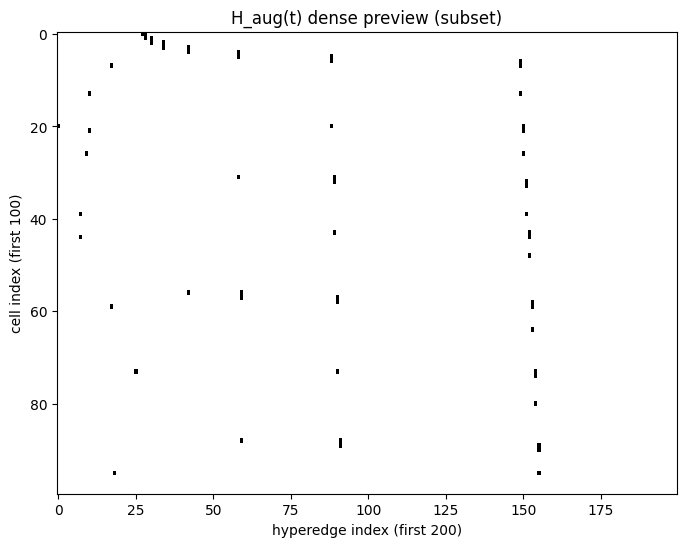

In [9]:
dense = batch.to_dense()
nnz_fraction = (dense != 0).float().mean().item()
print(f'Dense H_aug(t={T_SAMPLE}) shape: {tuple(dense.shape)}, nonzero fraction: {nnz_fraction:.5f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(dense[:100, :200].numpy(), aspect='auto', cmap='Greys')
ax.set_xlabel('hyperedge index (first 200)')
ax.set_ylabel('cell index (first 100)')
ax.set_title('H_aug(t) dense preview (subset)')
plt.show()


## Summary

- `H_aug(t)` is assembled as a sparse `HyperedgeBatch` from 4 sources: spatial (dynamic, DBSCAN), lineage (static, 642 edges), functional (static, 4436 edges), anastomosis (dynamic).
- At t=100 this gives a ~1625 x ~5100 incidence matrix with a clear block structure by edge type.
- Next: **notebook 03** runs Hyper-SAGNN vertex convolution over `H_aug(t)`.